#Importing Libraries and exploring data

In [529]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [530]:
df = pd.read_csv("train_data.csv")

In [531]:
df.head()


,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,LegalNotice,Reviews,SupportedLanguages,Website,PCMinReqsText,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,,,English French German Italian Spanish Simplifi...,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,,,English French German Italian Spanish,http://www.dayofdefeat.com/,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,,,English French German Korean,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,


In [532]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   QueryID                      11357 non-null  int64  
 1   ResponseID                   11357 non-null  int64  
 2   QueryName                    11356 non-null  object 
 3   ResponseName                 11357 non-null  object 
 4   ReleaseDate                  11357 non-null  object 
 5   RequiredAge                  11357 non-null  int64  
 6   DemoCount                    11357 non-null  int64  
 7   DeveloperCount               11357 non-null  int64  
 8   DLCCount                     11357 non-null  int64  
 9   Metacritic                   11357 non-null  int64  
 10  MovieCount                   11357 non-null  int64  
 11  PackageCount                 11357 non-null  int64  
 12  RecommendationCount          11357 non-null  int64  
 13  PublisherCount  

In [533]:
df.shape

(11357, 78)

In [534]:
df["Reviews"].head()

,Reviews
0,
1,
2,
3,
4,


#Preproccessing

In [535]:
df = df.replace(r'^\s*$', np.nan, regex=True)

In [536]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   QueryID                      11357 non-null  int64  
 1   ResponseID                   11357 non-null  int64  
 2   QueryName                    11356 non-null  object 
 3   ResponseName                 11357 non-null  object 
 4   ReleaseDate                  11284 non-null  object 
 5   RequiredAge                  11357 non-null  int64  
 6   DemoCount                    11357 non-null  int64  
 7   DeveloperCount               11357 non-null  int64  
 8   DLCCount                     11357 non-null  int64  
 9   Metacritic                   11357 non-null  int64  
 10  MovieCount                   11357 non-null  int64  
 11  PackageCount                 11357 non-null  int64  
 12  RecommendationCount          11357 non-null  int64  
 13  PublisherCount  

In [537]:
cols_to_drop = [
    "QueryID", "ResponseID", "QueryName", "ResponseName",
    "AboutText", "Background", "ShortDescrip", "DetailedDescrip",
    "SupportEmail", "SupportURL", "Website",
    "PCMinReqsText", "PCRecReqsText", "LinuxMinReqsText", "LinuxRecReqsText",
    "MacMinReqsText", "MacRecReqsText",
    "LegalNotice", "DRMNotice", "ExtUserAcctNotice",
    "Reviews", "HeaderImage", "PriceCurrency", "ReleaseDate",
    "RequiredAge", "PackageCount", "DLCCount",
    "SteamSpyOwnersVariance", "SteamSpyPlayersVariance", "ScreenshotCount","SupportedLanguages"
]


In [538]:
df = df.drop(columns=cols_to_drop)

In [539]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DemoCount                    11357 non-null  int64  
 1   DeveloperCount               11357 non-null  int64  
 2   Metacritic                   11357 non-null  int64  
 3   MovieCount                   11357 non-null  int64  
 4   RecommendationCount          11357 non-null  int64  
 5   PublisherCount               11357 non-null  int64  
 6   SteamSpyOwners               11357 non-null  int64  
 7   SteamSpyPlayersEstimate      11357 non-null  int64  
 8   AchievementCount             11357 non-null  int64  
 9   AchievementHighlightedCount  11357 non-null  int64  
 10  ControllerSupport            11357 non-null  bool   
 11  IsFree                       11357 non-null  bool   
 12  FreeVerAvail                 11357 non-null  bool   
 13  PurchaseAvail   

In [540]:
num_cols = [
    "DemoCount",
    "DeveloperCount",
    "Metacritic",
    "MovieCount",
    "RecommendationCount",
    "PublisherCount",
    "SteamSpyOwners",
    "SteamSpyPlayersEstimate",
    "AchievementCount",
    "AchievementHighlightedCount",
    "PriceInitial",
    "PriceFinal"
]
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = (df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))

outlier_count = outliers.sum().sort_values(ascending=False)
print(outlier_count)
rows_with_outliers = outliers.any(axis=1).sum()

print("Rows with at least one outlier:", rows_with_outliers)
print("Percentage:", rows_with_outliers / len(df) * 100)
df[num_cols] = df[num_cols].clip(
    df[num_cols].quantile(0.01),
    df[num_cols].quantile(0.99),
    axis=1
)


Metacritic                     1931
SteamSpyPlayersEstimate        1814
RecommendationCount            1754
SteamSpyOwners                 1728
DeveloperCount                 1273
PublisherCount                 1146
DemoCount                      1000
PriceInitial                    700
PriceFinal                      666
AchievementCount                644
MovieCount                      459
AchievementHighlightedCount       0
dtype: int64
Rows with at least one outlier: 5477
Percentage: 48.22576384608611


In [541]:
num_cols = df.select_dtypes(include=[np.number]).columns

df = df[(df[num_cols] >= 0).all(axis=1)]

In [542]:
skew_cols = [
    "SteamSpyOwners",
    "SteamSpyPlayersEstimate",
    "PriceInitial",
    "PriceFinal"
]

for col in skew_cols:
    df[col] = np.log1p(df[col])

In [543]:
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

In [544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 0 to 11356
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DemoCount                    11357 non-null  int64  
 1   DeveloperCount               11357 non-null  int64  
 2   Metacritic                   11357 non-null  int64  
 3   MovieCount                   11357 non-null  int64  
 4   RecommendationCount          11357 non-null  float64
 5   PublisherCount               11357 non-null  int64  
 6   SteamSpyOwners               11357 non-null  float64
 7   SteamSpyPlayersEstimate      11357 non-null  float64
 8   AchievementCount             11357 non-null  int64  
 9   AchievementHighlightedCount  11357 non-null  int64  
 10  ControllerSupport            11357 non-null  int64  
 11  IsFree                       11357 non-null  int64  
 12  FreeVerAvail                 11357 non-null  int64  
 13  PurchaseAvail   

In [545]:
df.nunique()

,0
DemoCount,2
DeveloperCount,4
Metacritic,62
MovieCount,7
RecommendationCount,1762
PublisherCount,3
SteamSpyOwners,2063
SteamSpyPlayersEstimate,1640
AchievementCount,107
AchievementHighlightedCount,11


In [546]:
df.isnull().sum()

,0
DemoCount,0
DeveloperCount,0
Metacritic,0
MovieCount,0
RecommendationCount,0
PublisherCount,0
SteamSpyOwners,0
SteamSpyPlayersEstimate,0
AchievementCount,0
AchievementHighlightedCount,0


/tmp/ipykernel_6482/2278373915.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_correlated_features.values, y=top_10_correlated_features.index, palette='viridis')


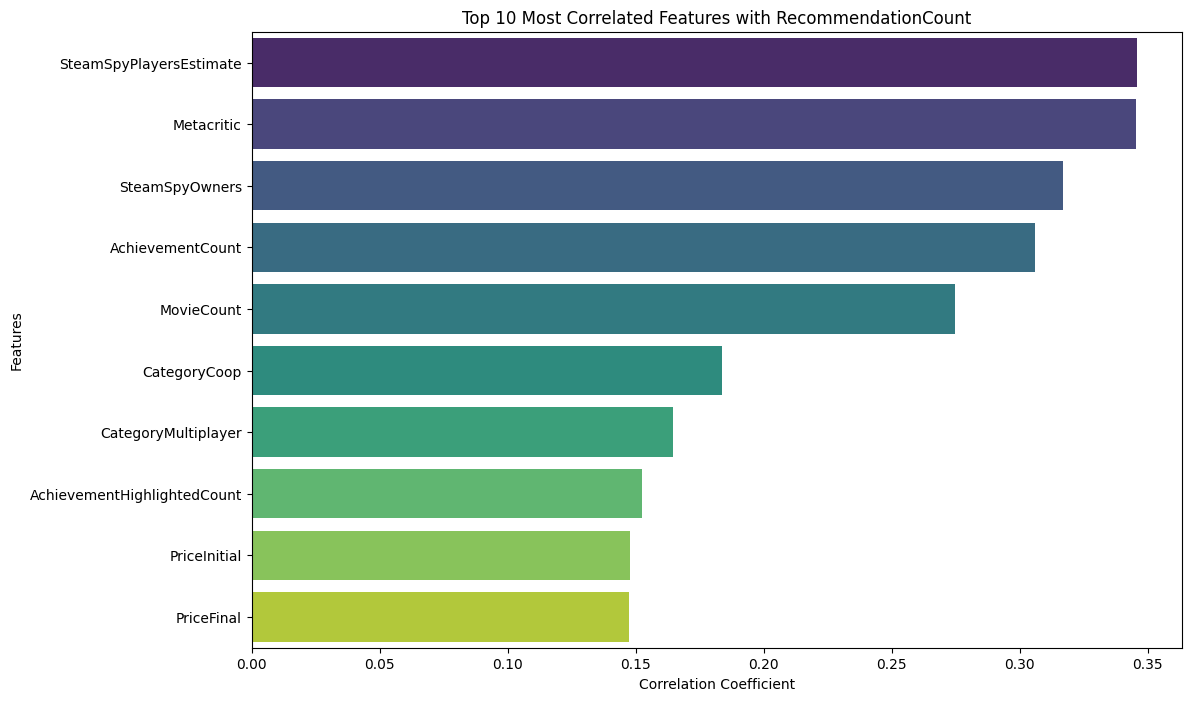

In [547]:
correlation_matrix = df.corr()
recommendation_corr = correlation_matrix['RecommendationCount'].sort_values(ascending=False)

# Exclude 'RecommendationCount' itself and get the top 10
top_10_correlated_features = recommendation_corr[1:11]

plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_correlated_features.values, y=top_10_correlated_features.index, palette='viridis')
plt.title('Top 10 Most Correlated Features with RecommendationCount')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()


#Modeling

In [548]:
y = df["RecommendationCount"]
X = df.drop("RecommendationCount", axis=1)

##Scaling

In [549]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


In [550]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


##lightgbm

In [551]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM R2:", r2_score(y_test, y_pred_lgbm))
print("MAE:", mean_absolute_error(y_test, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 915
[LightGBM] [Info] Number of data points in the train set: 9085, number of used features: 43
[LightGBM] [Info] Start training from score 748.148474
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

##XGBoost

In [552]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: 0.8306940754551023
MAE: 330.87123193880615


##Random Forest

In [553]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R2: 0.8308291090466489
MAE: 325.14222664058616


In [554]:
feature_names = df.drop(columns=["RecommendationCount"]).columns
X_train = pd.DataFrame(X_train, columns=feature_names)
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

,0
SteamSpyPlayersEstimate,0.781755
SteamSpyOwners,0.034992
PriceFinal,0.020374
Metacritic,0.019870
PriceInitial,0.019654
AchievementCount,0.018993
MovieCount,0.018559
GenreIsAdventure,0.007215
ControllerSupport,0.007095
GenreIsStrategy,0.006605


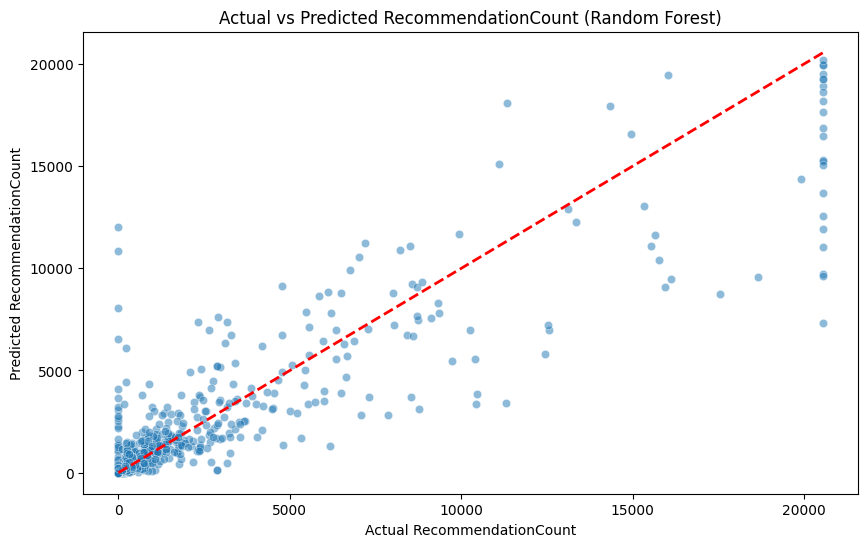

In [555]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual RecommendationCount')
plt.ylabel('Predicted RecommendationCount')
plt.title('Actual vs Predicted RecommendationCount (Random Forest)')
plt.show()